In [13]:
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "1")

import tensorflow as tf
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Visualization & Metrics
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Performance / device setup
print("TensorFlow:", tf.__version__)
gpus = tf.config.list_physical_devices("GPU")
USE_GPU = len(gpus) > 0
if USE_GPU:
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except Exception:
            pass
    from tensorflow.keras import mixed_precision
    mixed_precision.set_global_policy("mixed_float16")
    print("GPUs:", gpus)
else:
    print("GPUs: none (TensorFlow will use CPU).")
    print("Tip: On Windows, TensorFlow GPU is typically available via WSL2 (Ubuntu) + NVIDIA drivers.")

# XLA (jit_compile) usually helps on GPU
USE_JIT = USE_GPU

TensorFlow: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
DATASET_PATH = "Detect_solar_dust"
import os
print("Contents of dataset folder:", os.listdir(DATASET_PATH))

for d in os.listdir(DATASET_PATH):
      folder = os.path.join(DATASET_PATH, d)
      if os.path.isdir(folder):
          print(f"{d} → {len(os.listdir(folder))} files")


Contents of dataset folder: ['Clean', 'Dusty']
Clean → 1493 files
Dusty → 1069 files


In [3]:
import os
import shutil
import tensorflow as tf
import numpy as np

IMG_SIZE = (299, 299)
BATCH_SIZE = 32
SEED = 1337
AUTOTUNE = tf.data.AUTOTUNE

# Force clear cache
CACHE_DIR = os.path.join(os.getcwd(), ".tf_data_cache_solar")
if os.path.exists(CACHE_DIR):
    print(f"Clearing old cache at {CACHE_DIR}...")
    try:
        shutil.rmtree(CACHE_DIR)
    except Exception as e:
        print(f"Warning: Could not delete cache. Delete '{CACHE_DIR}' manually.")
os.makedirs(CACHE_DIR, exist_ok=True)

# MUCH stronger augmentation to slow down memorization
# The dataset is small (~2000 train images), so we need to make each image 
# look very different every epoch to prevent the model from memorizing pixel patterns.
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal_and_vertical"),  # Both axes
        tf.keras.layers.RandomRotation(factor=0.2, fill_mode="nearest"),  # ±72 degrees
        tf.keras.layers.RandomTranslation(height_factor=0.2, width_factor=0.2, fill_mode="nearest"),
        tf.keras.layers.RandomZoom(height_factor=(-0.3, 0.3), fill_mode="nearest"),
        tf.keras.layers.RandomBrightness(factor=0.2),  # Doubled
        tf.keras.layers.RandomContrast(factor=0.2),  # Doubled
    ],
    name="data_augmentation",
)

train_raw = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    labels="inferred",
    label_mode="binary",
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_raw = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    labels="inferred",
    label_mode="binary",
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

# Verify class balance
print("\nVerifying Validation Split Balance...")
y_val = []
for _, labels in val_raw:
    y_val.extend(labels.numpy().flatten())
unique, counts = np.unique(y_val, return_counts=True)
print(f"Validation Class Distribution: {dict(zip(unique, counts))}")
print(f"Class Names: {train_raw.class_names}\n")

def train_preprocess(images, labels):
    images = data_augmentation(images, training=True)
    images = preprocess_input(tf.cast(images, tf.float32))
    return images, labels

def val_preprocess(images, labels):
    images = preprocess_input(tf.cast(images, tf.float32))
    return images, labels

# NO caching for train - forces fresh augmentation every epoch (critical for small data)
train_data = (
    train_raw
    .map(train_preprocess, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

val_data = (
    val_raw
    .map(val_preprocess, num_parallel_calls=AUTOTUNE)
    .cache(os.path.join(CACHE_DIR, "val"))
    .prefetch(AUTOTUNE)
)

Clearing old cache at /home/sanjeev/solar_panel_project/.tf_data_cache_solar...
Found 2562 files belonging to 2 classes.
Using 2050 files for training.


I0000 00:00:1773334528.922924    1450 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5560 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Found 2562 files belonging to 2 classes.
Using 512 files for validation.

Verifying Validation Split Balance...


2026-03-12 16:55:30.501266: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2026-03-12 16:55:30.501363: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: cHRM chunk does not match sRGB


Validation Class Distribution: {np.float32(0.0): np.int64(290), np.float32(1.0): np.int64(222)}
Class Names: ['Clean', 'Dusty']



In [4]:
base_model = InceptionV3(
    weights="imagenet",
    include_top=False,
    input_shape=(299, 299, 3)
)

# Freeze base model
base_model.trainable = False

In [5]:
# Classification Head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)

output = Dense(1, activation="sigmoid", dtype="float32")(x)

model = Model(inputs=base_model.input, outputs=output)

# Lower initial LR to slow down learning on head (prevents early memorization)
model.compile(
    optimizer=Adam(learning_rate=5e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"],
    jit_compile=USE_JIT,
)

In [6]:
# Callbacks 

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "best_inception_solar.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_accuracy",
        mode="max",
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1
    ),
]

# Phase 1: Train classification head
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=50,
    callbacks=callbacks
)

Epoch 1/50


2026-03-12 16:55:34.848670: E tensorflow/core/util/util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


 2/65 ━━━━━━━━━━━━━━━━━━━━ 6s 105ms/step - accuracy: 0.5547 - loss: 0.7776 

I0000 00:00:1773334558.959659    1541 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


25/65 ━━━━━━━━━━━━━━━━━━━━ 6s 170ms/step - accuracy: 0.5154 - loss: 0.7690

...

35/65 ━━━━━━━━━━━━━━━━━━━━ 5s 185ms/step - accuracy: 0.7476 - loss: 0.4812

2026-03-12 17:03:51.473637: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2026-03-12 17:03:51.474369: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: cHRM chunk does not match sRGB


36/65 ━━━━━━━━━━━━━━━━━━━━ 5s 186ms/step - accuracy: 0.7478 - loss: 0.4812

Corrupt JPEG data: 1 extraneous bytes before marker 0xed
2026-03-12 17:03:51.926791: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2026-03-12 17:03:51.926955: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: cHRM chunk does not match sRGB


63/65 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.7535 - loss: 0.4786
Epoch 31: val_accuracy did not improve from 0.79102

Epoch 31: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.
65/65 ━━━━━━━━━━━━━━━━━━━━ 14s 197ms/step - accuracy: 0.7576 - loss: 0.4740 - val_accuracy: 0.7891 - val_loss: 0.4686 - learning_rate: 2.5000e-05
Epoch 31: early stopping
Restoring model weights from the end of the best epoch: 23.


In [15]:
# Phase 2: Fine-Tuning

fine_tune_callbacks = [
    EarlyStopping(
        monitor='val_accuracy', 
        patience=15,             
        restore_best_weights=True, 
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_accuracy', 
        factor=0.5,              
        patience=6,              
        min_lr=1e-7,             
        verbose=1
    ),
    ModelCheckpoint(
        filepath='best_finetuned_model.keras', 
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

base_model.trainable = True

for layer in base_model.layers:
    layer.trainable = False

for layer in base_model.layers[-50:]:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
    loss="binary_crossentropy",
    metrics=["accuracy"],
    jit_compile=USE_JIT,
)

print("Trainable variables:", len(model.trainable_variables))

fine_tune_history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=75, 
    callbacks=fine_tune_callbacks 
)

Trainable variables: 16
Epoch 1/75


18/65 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - accuracy: 0.8477 - loss: 0.3302

2026-03-12 17:17:51.701914: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: profile 'ICC Profile': 0h: PCS illuminant is not D50


30/65 ━━━━━━━━━━━━━━━━━━━━ 5s 159ms/step - accuracy: 0.8424 - loss: 0.3428

Corrupt JPEG data: 1 extraneous bytes before marker 0xed


...

33/65 ━━━━━━━━━━━━━━━━━━━━ 6s 188ms/step - accuracy: 0.8796 - loss: 0.3007

2026-03-12 17:27:14.616980: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2026-03-12 17:27:14.617420: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: cHRM chunk does not match sRGB
2026-03-12 17:27:14.933106: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2026-03-12 17:27:14.933326: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: cHRM chunk does not match sRGB


36/65 ━━━━━━━━━━━━━━━━━━━━ 5s 197ms/step - accuracy: 0.8794 - loss: 0.3002

Corrupt JPEG data: 1 extraneous bytes before marker 0xed


64/65 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.8787 - loss: 0.3019
Epoch 38: val_accuracy did not improve from 0.84766
65/65 ━━━━━━━━━━━━━━━━━━━━ 15s 217ms/step - accuracy: 0.8732 - loss: 0.3108 - val_accuracy: 0.8438 - val_loss: 0.3898 - learning_rate: 3.1250e-07
Epoch 38: early stopping
Restoring model weights from the end of the best epoch: 23.


In [16]:
val_loss, val_acc = model.evaluate(val_data)
print(f"Validation Accuracy: {val_acc:.4f}")


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8477 - loss: 0.3906
Validation Accuracy: 0.8477


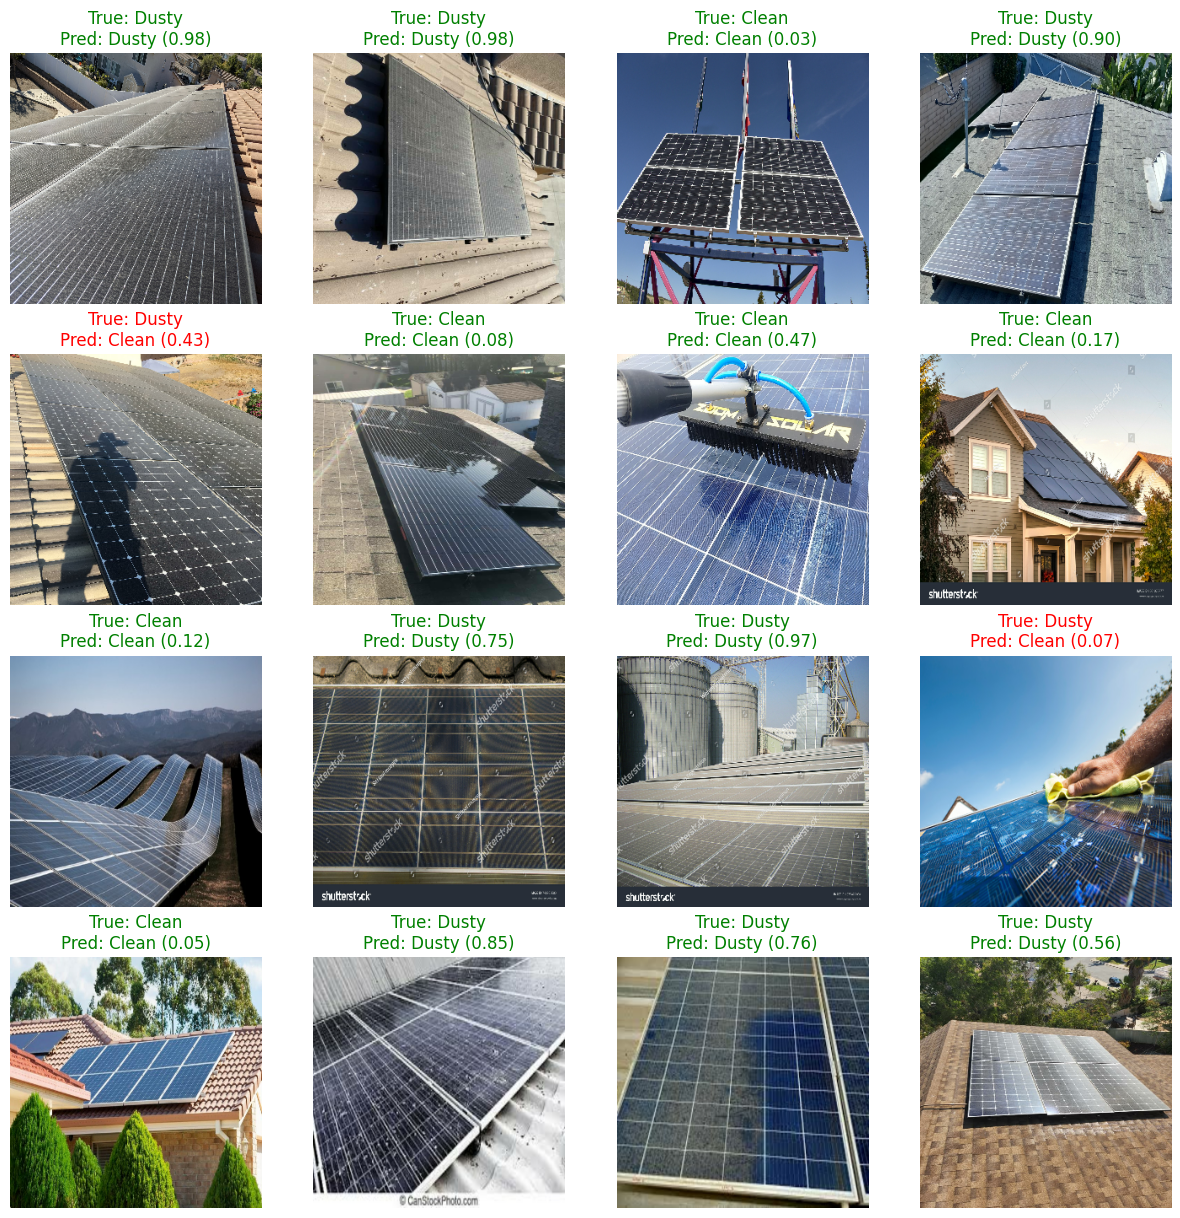

In [17]:
# --- VISUALIZATION: Prediction Examples ---
def show_predictions(dataset, model, class_names, num_images=16):
    plt.figure(figsize=(15, 15))
    
    # Take one batch
    for images, labels in dataset.take(1):
        # Predict batch
        preds = model.predict(images, verbose=0)
        
        for i in range(num_images):
            ax = plt.subplot(4, 4, i + 1)
            
            # Image needs to be un-normalized for display if we used preprocess_input
            # InceptionV3 preprocess maps to [-1, 1], so (x+1)/2 * 255 puts it back roughly to [0,255]
            img_disp = images[i].numpy()
            img_disp = (img_disp + 1.0) / 2.0 
            plt.imshow(np.clip(img_disp, 0, 1))
            
            # FIX: labels[i] is shape (1,), need to access index 0 to get the scalar
            true_label = class_names[int(labels[i].numpy()[0])]
            
            pred_conf = preds[i][0]
            pred_label = class_names[int(pred_conf > 0.5)]
            
            # Color code title: Green = Correct, Red = Wrong
            color = 'green' if true_label == pred_label else 'red'
            
            plt.title(f"True: {true_label}\nPred: {pred_label} ({pred_conf:.2f})", color=color)
            plt.axis("off")
    plt.show()

# Show 'em
show_predictions(val_data, model, train_raw.class_names)

Generating predictions for Confusion Matrix...
16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step


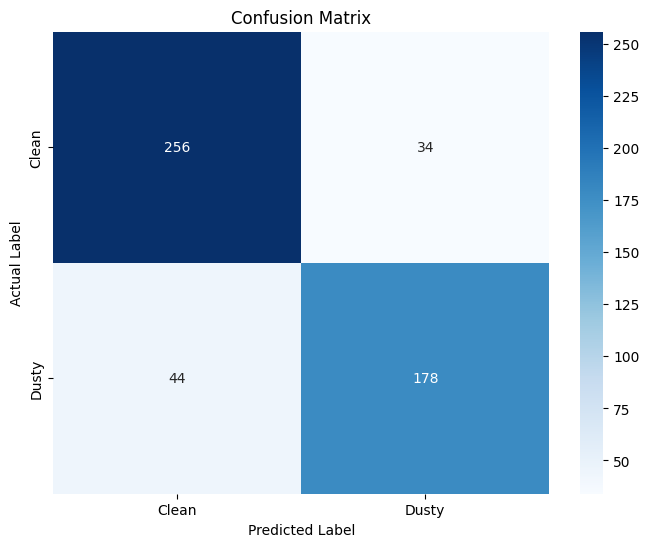


Classification Report:

              precision    recall  f1-score   support

       Clean       0.85      0.88      0.87       290
       Dusty       0.84      0.80      0.82       222

    accuracy                           0.85       512
   macro avg       0.85      0.84      0.84       512
weighted avg       0.85      0.85      0.85       512



In [18]:
# --- VISUALIZATION: Confusion Matrix ---

# 1. Get Predictions
print("Generating predictions for Confusion Matrix...")
y_pred_probs = model.predict(val_data, verbose=1)
y_pred = (y_pred_probs > 0.5).astype("int32").flatten()

# 2. Get True Labels (Iterate safely to ensure alignment)
y_true = []
for images, labels in val_data:
    y_true.extend(labels.numpy().astype("int32"))
y_true = np.array(y_true)

# 3. Create Matrix
cm = confusion_matrix(y_true, y_pred)
class_names = train_raw.class_names # ['Clean', 'Dusty'] typically

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.show()

# 4. Text Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

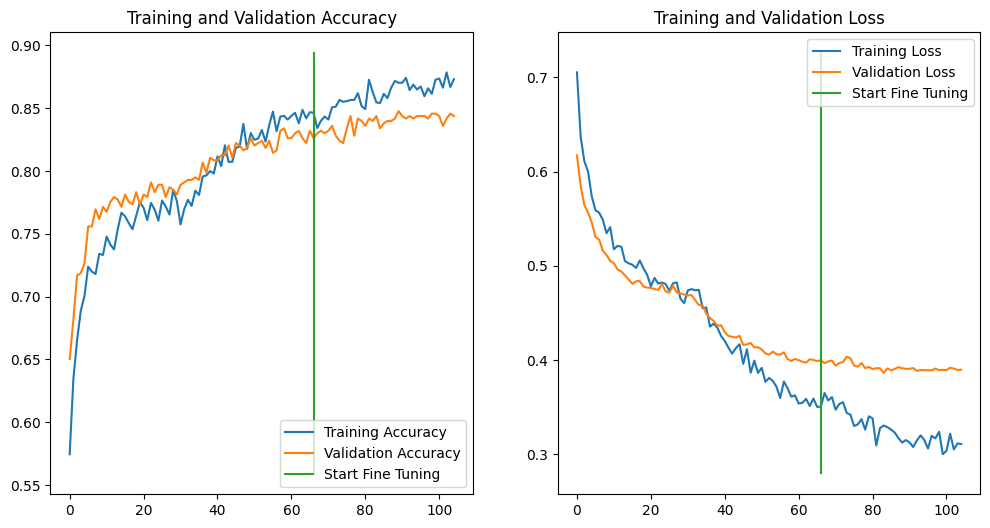

In [19]:
# --- VISUALIZATION: Training Metrics ---
def plot_history(initial_hist, fine_tune_hist=None, initial_epochs=10):
    acc = initial_hist.history['accuracy']
    val_acc = initial_hist.history['val_accuracy']
    loss = initial_hist.history['loss']
    val_loss = initial_hist.history['val_loss']

    if fine_tune_hist:
        acc += fine_tune_hist.history['accuracy']
        val_acc += fine_tune_hist.history['val_accuracy']
        loss += fine_tune_hist.history['loss']
        val_loss += fine_tune_hist.history['val_loss']

    plt.figure(figsize=(12, 6))
    
    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(acc, label='Training Accuracy')
    plt.plot(val_acc, label='Validation Accuracy')
    if fine_tune_hist:
        plt.plot([initial_epochs-1, initial_epochs-1], 
                 plt.ylim(), label='Start Fine Tuning')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(loss, label='Training Loss')
    plt.plot(val_loss, label='Validation Loss')
    if fine_tune_hist:
        plt.plot([initial_epochs-1, initial_epochs-1], 
                 plt.ylim(), label='Start Fine Tuning')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    
    plt.show()

# Detect if we have fine_tune_history, otherwise just pass None
ft_hist = fine_tune_history if 'fine_tune_history' in locals() else None
init_epochs = len(history.history['accuracy'])
plot_history(history, ft_hist, initial_epochs=init_epochs)